<a href="https://colab.research.google.com/github/ammar-iitm/foveamap/blob/main/notebooks/foveamap_nuscenes_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FoveaMap on real Lidar: nuScenes-mini

This notebook runs the FoveaMap prototype on **real Lidar data** from nuScenes-mini (10 scenes, 32-beam Velodyne, about 4 GB). It works through these steps:

1. Downloads nuScenes-mini and the nuScenes-lidarseg labels.
2. Checks the loader on one frame and plots it.
3. Measures how the **simulator-trained** model does on real data, before any fine-tuning.
4. **Fine-tunes** the model on the 8 `mini_train` scenes, using the GPU.
5. Runs the full benchmark on a `mini_val` scene with both grid engines (NumPy on the CPU, PyTorch on the GPU): latency, memory, and accuracy by distance.
6. Exports the dashboard data and zips everything for download.

**Before you start:** use *Runtime → Change runtime type → T4 GPU*. The whole notebook takes roughly 15–25 minutes.

nuScenes is free for non-commercial use under its [terms of use](https://www.nuscenes.org/terms-of-use).

## 1. Setup

In [18]:
!nvidia-smi --query-gpu=name,memory.total --format=csv || echo "No GPU: Runtime > Change runtime type > T4 GPU"

name, memory.total [MiB]
Tesla T4, 15360 MiB


Get the code: this cell clones the latest `main` from [GitHub](https://github.com/ammar-iitm/foveamap), replacing any older copy in this runtime. To run a local copy instead, set `USE_ZIP = True` and upload the code zip when asked (or set `ZIP_IN_DRIVE` to its path in Google Drive).

In [19]:
import os, sys, shutil, zipfile, importlib
REPO = 'https://github.com/ammar-iitm/foveamap.git'
USE_ZIP = False       # True: upload a code zip instead of cloning
ZIP_IN_DRIVE = None   # e.g. '/content/drive/MyDrive/foveamap.zip'

%cd /content
shutil.rmtree('/content/foveamap', ignore_errors=True)            # always start from a fresh copy
if not USE_ZIP:
    !git clone -q --depth 1 $REPO /content/foveamap
elif ZIP_IN_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    zipfile.ZipFile(ZIP_IN_DRIVE).extractall('/content')
else:
    from google.colab import files
    up = files.upload()
    zipfile.ZipFile(next(iter(up))).extractall('/content')
if not os.path.exists('/content/foveamap/foveamap/grid_torch.py'):
    raise FileNotFoundError('This copy of the code has no PyTorch grid engine (foveamap/grid_torch.py).')
for m in [m for m in list(sys.modules) if m == 'foveamap' or m.startswith('foveamap.')]:
    del sys.modules[m]                                            # forget any old import
importlib.invalidate_caches()
%cd /content/foveamap
!pip -q install -r requirements.txt
!git log --oneline -1 2>/dev/null; ls foveamap

/content
/content/foveamap
626df42 (grafted, HEAD -> main, origin/main, origin/HEAD) Test that the packed snapshot matches the device state exactly
features_torch.py  grid.py	  __init__.py  nuscenes.py  sim.py
frames.py	   grid_torch.py  model.py     pipeline.py


## 2. Download nuScenes-mini + lidarseg

If a download fails (for example, the site asks you to log in), register for free at [nuscenes.org](https://www.nuscenes.org/nuscenes#download). Then download **Mini** (`v1.0-mini.tgz`) and **nuScenes-lidarseg → Mini** (`nuScenes-lidarseg-mini-v1.0.tar.bz2`), put both files in `/content/`, and rerun this cell.

In [20]:
DATAROOT = '/content/nuscenes'
os.makedirs(DATAROOT, exist_ok=True)

if not os.path.exists('/content/v1.0-mini.tgz'):
    !wget -q --show-progress -O /content/v1.0-mini.tgz https://www.nuscenes.org/data/v1.0-mini.tgz
if not os.path.exists('/content/nuScenes-lidarseg-mini-v1.0.tar.bz2'):
    !wget -q --show-progress -O /content/nuScenes-lidarseg-mini-v1.0.tar.bz2 https://www.nuscenes.org/data/nuScenes-lidarseg-mini-v1.0.tar.bz2

!tar -xzf /content/v1.0-mini.tgz -C $DATAROOT
!tar -xjf /content/nuScenes-lidarseg-mini-v1.0.tar.bz2 -C $DATAROOT

need = ['v1.0-mini/sample_data.json', 'v1.0-mini/lidarseg.json', 'samples/LIDAR_TOP', 'sweeps/LIDAR_TOP', 'lidarseg/v1.0-mini']
missing = [p for p in need if not os.path.exists(os.path.join(DATAROOT, p))]
print('missing:', missing if missing else 'nothing, data is ready')

missing: nothing, data is ready


## 3. Check the loader on one frame

nuScenes v1.0-mini: 10 scenes, 404 samples, 404 lidarseg files
lasers: 32 | mini_train: ['scene-0061', 'scene-0553', 'scene-0655', 'scene-0757', 'scene-0796', 'scene-1077', 'scene-1094', 'scene-1100'] | mini_val: ['scene-0103', 'scene-0916']
drivable surface           12757
sidewalk / other flat       2974
terrain                        0
vegetation                   688
manmade / static            8826
barrier / cone                 1
vehicle                      525
person                       290
moving points: 450 | prev sweeps: [True, True]


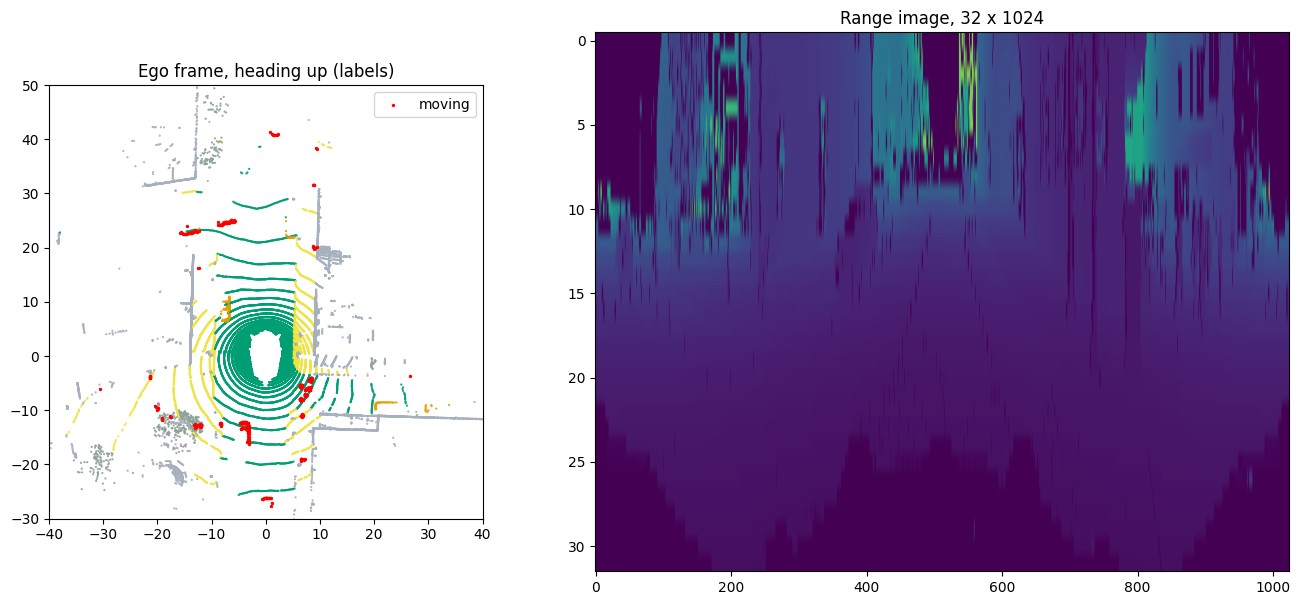

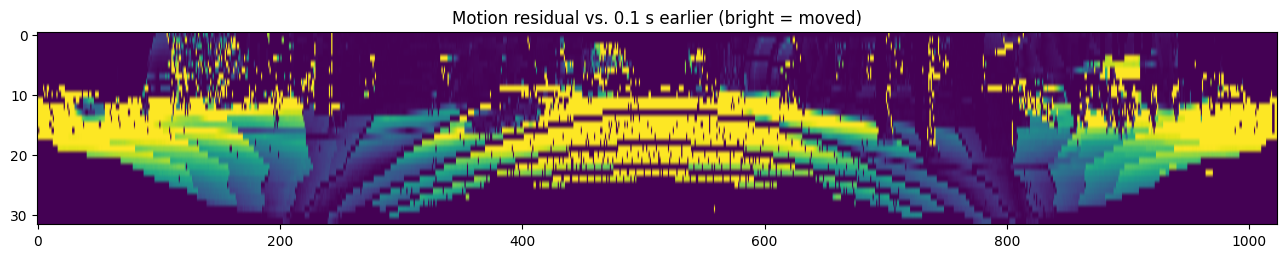

In [21]:
import numpy as np, matplotlib.pyplot as plt
from foveamap.nuscenes import NuScenesLite, nuscenes_info
from foveamap.frames import make_features, prev_in_ego

nusc = NuScenesLite(DATAROOT, 'v1.0-mini')
info = nuscenes_info(nusc.n_rings())
print('lasers:', info.n_rows, '| mini_train:', nusc.scene_names('mini_train'), '| mini_val:', nusc.scene_names('mini_val'))

toks = nusc.keyframe_tokens('scene-0103')
tok = toks[min(10, len(toks) - 1)]
f = nusc.frame(tok, info)
counts = np.bincount(f['label'][f['label'] >= 0], minlength=9)
for n, c, a in zip(info.class_names, counts, info.active):
    if a: print(f'{n:24s} {c:7d}')
print('moving points:', int(f['moving'].sum()), '| prev sweeps:', [p is not None for p in f['prev']])

feats, idx, _, _ = make_features(f, info, prev_in_ego(f))
COL = np.array(['#009E73','#F0E442','#3DBE93','#C9BD3A','#8FA39A','#A7B1BD','#DCE3EA','#E69F00','#CC79A7'])
fig, ax = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw=dict(width_ratios=[1, 1.6]))
m = f['label'] >= 0
ax[0].scatter(-f['pts'][m, 1], f['pts'][m, 0], s=0.3, c=COL[f['label'][m]])
ax[0].scatter(-f['pts'][f['moving'], 1], f['pts'][f['moving'], 0], s=2, c='red', label='moving')
ax[0].set_aspect('equal'); ax[0].set_xlim(-40, 40); ax[0].set_ylim(-30, 50); ax[0].set_title('Ego frame, heading up (labels)'); ax[0].legend()
ax[1].imshow(feats[0], aspect='auto', cmap='viridis'); ax[1].set_title(f'Range image, {info.n_rows} x {info.n_cols}')
plt.show()
plt.figure(figsize=(16, 2.5)); plt.imshow(feats[6], aspect='auto', vmax=1); plt.title('Motion residual vs. 0.1 s earlier (bright = moved)'); plt.show()

## 4. Convert all 10 scenes to cached frames (takes 2–4 minutes)

In [22]:
!python scripts/prepare_nuscenes.py --dataroot $DATAROOT --out cache/nuscenes
!du -sh cache/nuscenes

nuScenes v1.0-mini: 10 scenes, 404 samples, 404 lidarseg files
  mini_train: scene-0061 (39 frames)
  mini_train: scene-0553 (41 frames)
  mini_train: scene-0655 (41 frames)
  mini_train: scene-0757 (41 frames)
  mini_train: scene-0796 (40 frames)
  mini_train: scene-1077 (41 frames)
  mini_train: scene-1094 (40 frames)
  mini_train: scene-1100 (40 frames)
  mini_val: scene-0103 (40 frames)
  mini_val: scene-0916 (41 frames)
475M	cache/nuscenes


## 5. Simulator model on real data, before fine-tuning

This measures the gap between the simulator and real data: how well the model trained only on simulated streets labels real nuScenes points.

In [23]:
import sys, json
sys.path.insert(0, 'scripts')
from train import evaluate
from foveamap.nuscenes import load_cached, cached_info
from foveamap.model import load_model

info = cached_info('cache/nuscenes')
val = load_cached('cache/nuscenes', 'mini_val')
zero_shot = evaluate(load_model('checkpoints/range_unet.pt'), val, info)
print(json.dumps(zero_shot, indent=1))

{
 "miou": 0.09822779227728544,
 "miou_by_band": [
  0.10759632853127084,
  0.06993548005006231,
  0.03922867050040648,
  0.01488161167553861
 ],
 "iou_by_class": {
  "drivable surface": 0.7506,
  "sidewalk / other flat": 0.0002,
  "terrain": 0.0016,
  "vegetation": 0.0006,
  "manmade / static": 0.0182,
  "barrier / cone": 0.0,
  "vehicle": 0.0005,
  "person": 0.0141
 },
 "moving_iou": 0.030138932884798138
}


## 6. Fine-tune on `mini_train` (GPU, about 5 minutes on a T4)

Training starts from the simulator checkpoint. The unused `parking` class is masked out, because nuScenes has no parking label.

In [24]:
!python scripts/train.py --dataset nuscenes --cache cache/nuscenes --init checkpoints/range_unet.pt \
    --out checkpoints/range_unet_nuscenes.pt --epochs 120

nuscenes: 323 training frames, range image 32 x 1024, device cuda
initialised from checkpoints/range_unet.pt
step    25       2s  loss 1.681  lr 0.00050
step    50       3s  loss 0.689  lr 0.00099
step    75       4s  loss 0.550  lr 0.00098
step   100       5s  loss 0.485  lr 0.00098
step   125       6s  loss 0.445  lr 0.00097
step   150       7s  loss 0.417  lr 0.00097
step   175       9s  loss 0.393  lr 0.00096
step   200      10s  loss 0.378  lr 0.00096
step   225      11s  loss 0.369  lr 0.00095
step   250      12s  loss 0.364  lr 0.00095
step   275      13s  loss 0.340  lr 0.00094
step   300      14s  loss 0.340  lr 0.00094
step   325      15s  loss 0.327  lr 0.00093
step   350      16s  loss 0.303  lr 0.00093
step   375      17s  loss 0.293  lr 0.00092
step   400      18s  loss 0.302  lr 0.00092
step   425      19s  loss 0.277  lr 0.00091
step   450      20s  loss 0.278  lr 0.00091
step   475      21s  loss 0.267  lr 0.00090
step   500      22s  loss 0.271  lr 0.00090
step   525 

## 7. Full benchmark on a `mini_val` scene, and export the dashboard data

On a T4 the network takes only a few milliseconds, so the grid engine decides the latency. The scene runs with both engines: NumPy on Colab's CPU, PyTorch on the GPU with async export (`--export async`), and PyTorch on the GPU with post-loop export (`--export after`). The post-loop export run goes to `dashboard/data` and avoids background PNG compression competing with the main thread on Colab's 2 vCPUs.

In [25]:
SCENE = 'scene-0103'   # or 'scene-0916'
runs = [
    ('numpy', 'numpy', 'results/numpy', 'async'),
    ('torch_async', 'torch', 'results/torch_async', 'async'),
    ('torch', 'torch', 'dashboard/data', 'after'),
]
for tag, grid, out, exp in runs:
    !python scripts/run_benchmark.py --dataset nuscenes --cache cache/nuscenes --scene $SCENE \
        --ckpt checkpoints/range_unet_nuscenes.pt --grid $grid --export $exp --out $out > benchmark_{SCENE}_{tag}.log
    !tail -n 3 benchmark_{SCENE}_{tag}.log

  "points_lost": 0,
  "nesting_ok": true
}
  "points_lost": 0,
  "nesting_ok": true
}
  "points_lost": 0,
  "nesting_ok": true
}


In [26]:
import pandas as pd
dirs = {'numpy': 'results/numpy', 'torch_async': 'results/torch_async', 'torch': 'dashboard/data'}
R = {k: json.load(open(f'{d}/metrics.json'))['summary'] for k, d in dirs.items() if os.path.exists(f'{d}/metrics.json')}
cmp = lambda f: {g: f(s) for g, s in R.items()}
cols = {'numpy': 'NumPy (CPU)', 'torch_async': 'PyTorch GPU (async export)', 'torch': 'PyTorch GPU (post-loop export)'}
pd.DataFrame({
    'p50 / p95 latency (ms)': cmp(lambda s: f"{s['latency_ms']['p50']:.0f} / {s['latency_ms']['p95']:.0f}"),
    'Throughput (FPS)': cmp(lambda s: f"{s['fps']:.1f}"),
    'Grid engine (projection + fusion, ms)': cmp(lambda s: f"{s['grid_only_ms']:.1f}"),
    **{f'{k} (ms)': cmp(lambda s, k=k: f"{s['stages_ms'][k]:.1f}") for k in R['torch']['stages_ms']},
    'Export (ms, not in latency)': cmp(lambda s: f"{s['export_ms']:.0f}"),
    'Points lost': cmp(lambda s: s['points_lost']),
    'Drivable IoU on grid, 0-10 m': cmp(lambda s: f"{100*s['drivable_iou_grid_0_10']:.1f}%"),
}).T.rename(columns=cols)

,NumPy (CPU),PyTorch GPU (async export),PyTorch GPU (post-loop export)
p50 / p95 latency (ms),137 / 250,56 / 87,30 / 31
Throughput (FPS),6.2,17.1,33.4
"Grid engine (projection + fusion, ms)",127.2,33.0,16.1
preprocess (ms),24.3,14.5,6.8
inference (ms),7.4,6.2,3.0
projection (ms),33.1,10.3,5.3
fusion (ms),94.1,22.7,10.8
publish (ms),1.8,4.8,4.0
"Export (ms, not in latency)",208,173,141
Points lost,0,0,0


In [27]:
for k in ('torch_async', 'torch'):
    if k in R:
        p95 = R[k]['latency_ms']['p95']
        print(f"{cols[k]}: p95 = {p95:.0f} ms -> {'PASS' if p95 <= 50 else 'FAIL'} (target <= 50 ms)")

PyTorch GPU (async export): p95 = 87 ms -> FAIL (target <= 50 ms)
PyTorch GPU (post-loop export): p95 = 31 ms -> PASS (target <= 50 ms)


In [28]:
S = R['torch']
ft = json.load(open('checkpoints/range_unet_nuscenes_val.json'))
pct = lambda v: '—' if v is None else f'{100*v:.1f}%'
rows = [
    ('Hardware', S['hardware']),
    ('End-to-end latency p50 / p95', f"{S['latency_ms']['p50']:.0f} / {S['latency_ms']['p95']:.0f} ms"),
    ('Throughput', f"{S['fps']:.1f} FPS"),
    ('Stage means (ms)', ', '.join(f'{k} {v:.0f}' for k, v in S['stages_ms'].items())),
    ('Map memory', f"{S['memory_bytes']['foveated_spec']/1e6:.2f} MB"),
    ('Saving vs uniform 5 cm', f"{S['memory_saving_vs_uniform5']:.0f}x"),
    ('Points lost at tier edges', S['points_lost']),
    ('Val mIoU, simulator model (zero-shot)', pct(zero_shot['miou'])),
    ('Val mIoU, fine-tuned', pct(ft['miou'])),
    ('Point mIoU by band (0-10/10-25/25-50/50-100 m)', ' / '.join(pct(v) for v in S['point_miou_by_band'])),
    ('Grid-cell mIoU by band', ' / '.join(pct(v) for v in S['grid_miou_by_band'])),
    ('Drivable IoU on grid, 0-10 m', pct(S['drivable_iou_grid_0_10'])),
    ('Moving-object IoU', pct(S['moving_iou'])),
]
pd.set_option('display.max_colwidth', 120)
pd.DataFrame(rows, columns=['Check', 'Result'])

,Check,Result
0,Hardware,Tesla T4 GPU (FP16 inference) + GPU grid engine
1,End-to-end latency p50 / p95,30 / 31 ms
2,Throughput,33.4 FPS
3,Stage means (ms),"preprocess 7, inference 3, projection 5, fusion 11, publish 4"
4,Map memory,5.12 MB
5,Saving vs uniform 5 cm,50x
6,Points lost at tier edges,0
7,"Val mIoU, simulator model (zero-shot)",9.8%
8,"Val mIoU, fine-tuned",46.3%
9,Point mIoU by band (0-10/10-25/25-50/50-100 m),44.8% / 43.5% / 30.8% / 15.4%


## 8. View the dashboard here

This serves the exported dashboard from the Colab machine and opens it in a frame below.

In [29]:
!python scripts/make_local_view.py
import subprocess, time
subprocess.Popen(['python', '-m', 'http.server', '8008'], cwd='dashboard', stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
time.sleep(1)
from google.colab import output
output.serve_kernel_port_as_iframe(8008, path='/view.html', height=900)

wrote /content/foveamap/scripts/../dashboard/view.html


<IPython.core.display.Javascript object>

## 9. Download the results

Send the zip back and I can publish the real-data dashboard and update the docs with these numbers.

In [30]:
!zip -qr /content/foveamap_nuscenes_results.zip dashboard results checkpoints/range_unet_nuscenes.pt checkpoints/range_unet_nuscenes_val.json benchmark_*.log
from google.colab import files
files.download('/content/foveamap_nuscenes_results.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [31]:
!grep '^frame' /content/foveamap/benchmark_scene-0103_torch_async.log
!grep '^frame' /content/foveamap/benchmark_scene-0103_torch.log


frame   0  total  1098.8 ms  preprocess 415  inference 292  projection 272  fusion 116  publish 4
frame   1  total    56.6 ms  preprocess 20  inference 11  projection 6  fusion 14  publish 5
frame   2  total    37.9 ms  preprocess 8  inference 4  projection 7  fusion 15  publish 4
frame   3  total    37.5 ms  preprocess 10  inference 4  projection 7  fusion 14  publish 2
frame   4  total    46.6 ms  preprocess 8  inference 6  projection 11  fusion 18  publish 3
frame   5  total    37.6 ms  preprocess 9  inference 4  projection 7  fusion 14  publish 3
frame   6  total    42.3 ms  preprocess 14  inference 4  projection 7  fusion 15  publish 2
frame   7  total    51.2 ms  preprocess 11  inference 4  projection 9  fusion 24  publish 3
frame   8  total    37.9 ms  preprocess 11  inference 4  projection 7  fusion 15  publish 2
frame   9  total    35.7 ms  preprocess 9  inference 4  projection 7  fusion 14  publish 2
frame  10  total    40.5 ms  preprocess 10  inference 4  projection 8  fusio